<a href="https://colab.research.google.com/github/fitraadhim/244107020089_MachineLearning/blob/main/KUIS1/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import tracemalloc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Load Dataset
file_path = "Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(file_path)

# 2. Cleaning Data & Handling Missing Values
df_clean = df.drop(columns=["Person ID"], errors="ignore")
df_clean["Sleep Disorder"] = df_clean["Sleep Disorder"].fillna("None")

# 3. Ekstraksi Fitur & Standardisation (Mean Normalization)
age_data = df_clean["Age"].values
sleep_data = df_clean["Sleep Duration"].values

scaler = StandardScaler()
X_2d = scaler.fit_transform(np.column_stack((age_data, sleep_data)))

print(f"Data berhasil diproses. Ukuran data: {X_2d.shape}")
print(f"Rata-rata fitur setelah mean normalization: Age={X_2d[:,0].mean():.2f}, Sleep Duration={X_2d[:,1].mean():.2f}")

Data berhasil diproses. Ukuran data: (374, 2)
Rata-rata fitur setelah mean normalization: Age=-0.00, Sleep Duration=0.00


In [18]:
# 1. Implementasi Rumus Jarak Modul GitBook
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def cosine_distance(x1, x2):
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    if norm_x1 == 0 or norm_x2 == 0:
        return 1.0
    return 1.0 - (dot_product / (norm_x1 * norm_x2))

# 2. Algoritma DBSCAN From Scratch
def dbscan_from_scratch(X, eps, min_samples, metric='euclidean'):
    if metric == 'euclidean':
        dist_func = euclidean_distance
    elif metric == 'manhattan':
        dist_func = manhattan_distance
    elif metric == 'cosine':
        dist_func = cosine_distance
    else:
        raise ValueError("Metrik tidak dikenali")

    n_samples = len(X)
    labels = np.full(n_samples, -1)  # -1 = Outlier / Noise
    visited = np.zeros(n_samples, dtype=bool)

    # Cari tetangga untuk semua titik dan tentukan core samples
    neighbors_list = []
    core_samples = []
    for i in range(n_samples):
        nbrs = [j for j in range(n_samples) if dist_func(X[i], X[j]) <= eps]
        neighbors_list.append(nbrs)
        if len(nbrs) >= min_samples:
            core_samples.append(i)

    core_set = set(core_samples)
    cluster_id = 0

    for i in range(n_samples):
        if visited[i]:
            continue
        visited[i] = True

        if i not in core_set:
            labels[i] = -1
        else:
            labels[i] = cluster_id
            seeds = list(neighbors_list[i])
            if i in seeds:
                seeds.remove(i)

            idx = 0
            while idx < len(seeds):
                curr_p = seeds[idx]
                if not visited[curr_p]:
                    visited[curr_p] = True
                    if curr_p in core_set:
                        for nbr in neighbors_list[curr_p]:
                            if nbr not in seeds:
                                seeds.append(nbr)

                if labels[curr_p] == -1:
                    labels[curr_p] = cluster_id

                idx += 1

            cluster_id += 1

    return labels, np.array(core_samples)

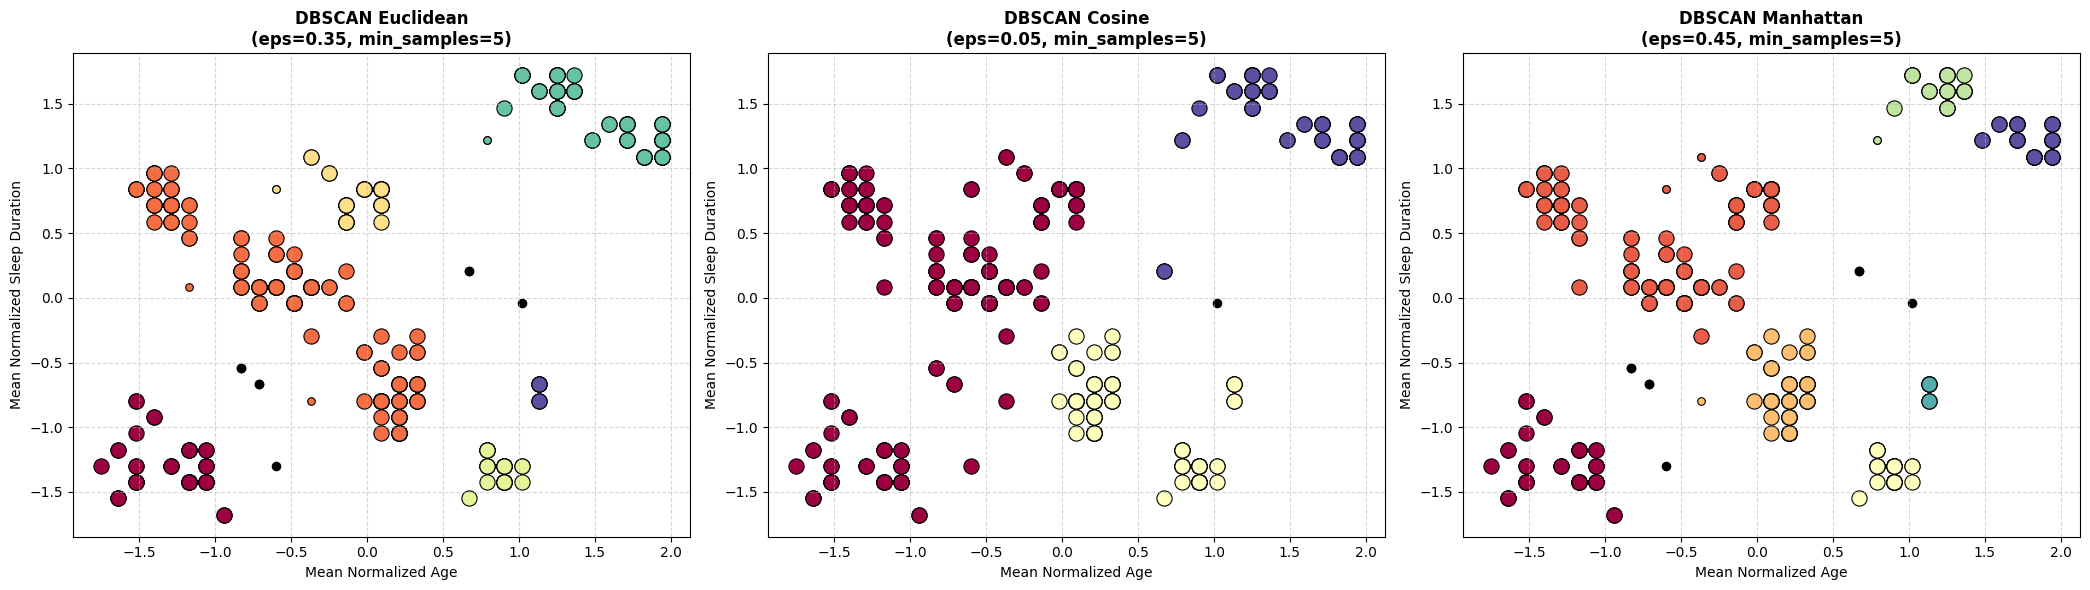

In [19]:
min_samples = 5
eps_optimal = {'euclidean': 0.35, 'cosine': 0.05, 'manhattan': 0.45}

# Running DBSCAN untuk 3 metrik
results_run = {}
for m in ['euclidean', 'cosine', 'manhattan']:
    lbls, cores = dbscan_from_scratch(X_2d, eps=eps_optimal[m], min_samples=min_samples, metric=m)
    results_run[m] = (lbls, cores)

# Plotting 3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
metrics = ['euclidean', 'cosine', 'manhattan']

for idx, m in enumerate(metrics):
    ax = axes[idx]
    labels, core_samples = results_run[m]

    unique_labels = set(labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels - {-1})))

    core_mask = np.zeros_like(labels, dtype=bool)
    if len(core_samples) > 0:
        core_mask[core_samples] = True

    # 1. Plot Outliers / Noise (Titik Hitam)
    noise_mask = (labels == -1)
    ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c='black', s=35, marker='o', label='Noise / Outlier')

    # 2. Plot Clustered Points (Core Samples = Lingkaran Besar, Non-Core = Lingkaran Kecil)
    col_idx = 0
    for k_label in sorted(list(unique_labels)):
        if k_label == -1:
            continue

        col = colors[col_idx]
        col_idx += 1
        class_member_mask = (labels == k_label)

        # Core Samples (Lingkaran Besar)
        xy_core = X_2d[class_member_mask & core_mask]
        ax.scatter(xy_core[:, 0], xy_core[:, 1], c=[col], s=120, edgecolors='k', linewidth=0.8)

        # Non-Core Samples (Lingkaran Kecil)
        xy_non_core = X_2d[class_member_mask & ~core_mask]
        ax.scatter(xy_non_core[:, 0], xy_non_core[:, 1], c=[col], s=30, edgecolors='k', linewidth=0.8)

    ax.set_title(f"DBSCAN {m.capitalize()}\n(eps={eps_optimal[m]}, min_samples={min_samples})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Mean Normalized Age", fontsize=10)
    ax.set_ylabel("Mean Normalized Sleep Duration", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
results = []
metrics_list = ['euclidean', 'cosine', 'manhattan']

for m in metrics_list:
    eps_val = eps_optimal[m]

    # Pengukuran Memori Peak & Waktu Eksekusi
    tracemalloc.start()
    start_time = time.perf_counter()

    labels, _ = dbscan_from_scratch(X_2d, eps=eps_val, min_samples=min_samples, metric=m)

    exec_time_ms = (time.perf_counter() - start_time) * 1000
    peak_memory_kb = tracemalloc.get_traced_memory()[1] / 1024
    tracemalloc.stop()

    # Hitung Jumlah Klaster & Silhouette Score (pada data non-noise)
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)

    non_noise_mask = (labels != -1)
    if n_clusters > 1 and np.sum(non_noise_mask) > 0:
        score = silhouette_score(X_2d[non_noise_mask], labels[non_noise_mask], metric=m)
        score_str = f"{score:.4f}"
    else:
        score_str = "N/A"

    results.append({
        "Metrik Jarak": m.capitalize(),
        "Jumlah Klaster": n_clusters,
        "Waktu Eksekusi (ms)": f"{exec_time_ms:.2f}",
        "Memori Peak (KB)": f"{peak_memory_kb:.2f}",
        "Silhouette Score": score_str
    })

df_results = pd.DataFrame(results)
print("="*65)
print("          HASIL EVALUASI DBSCAN FROM SCRATCH PER RUMUS          ")
print("="*65)
display(df_results)

          HASIL EVALUASI DBSCAN FROM SCRATCH PER RUMUS          


,Metrik Jarak,Jumlah Klaster,Waktu Eksekusi (ms),Memori Peak (KB),Silhouette Score
0,Euclidean,6,3490.26,296.98,0.3982
1,Cosine,3,6900.56,428.17,0.6181
2,Manhattan,7,2819.47,285.20,0.6243


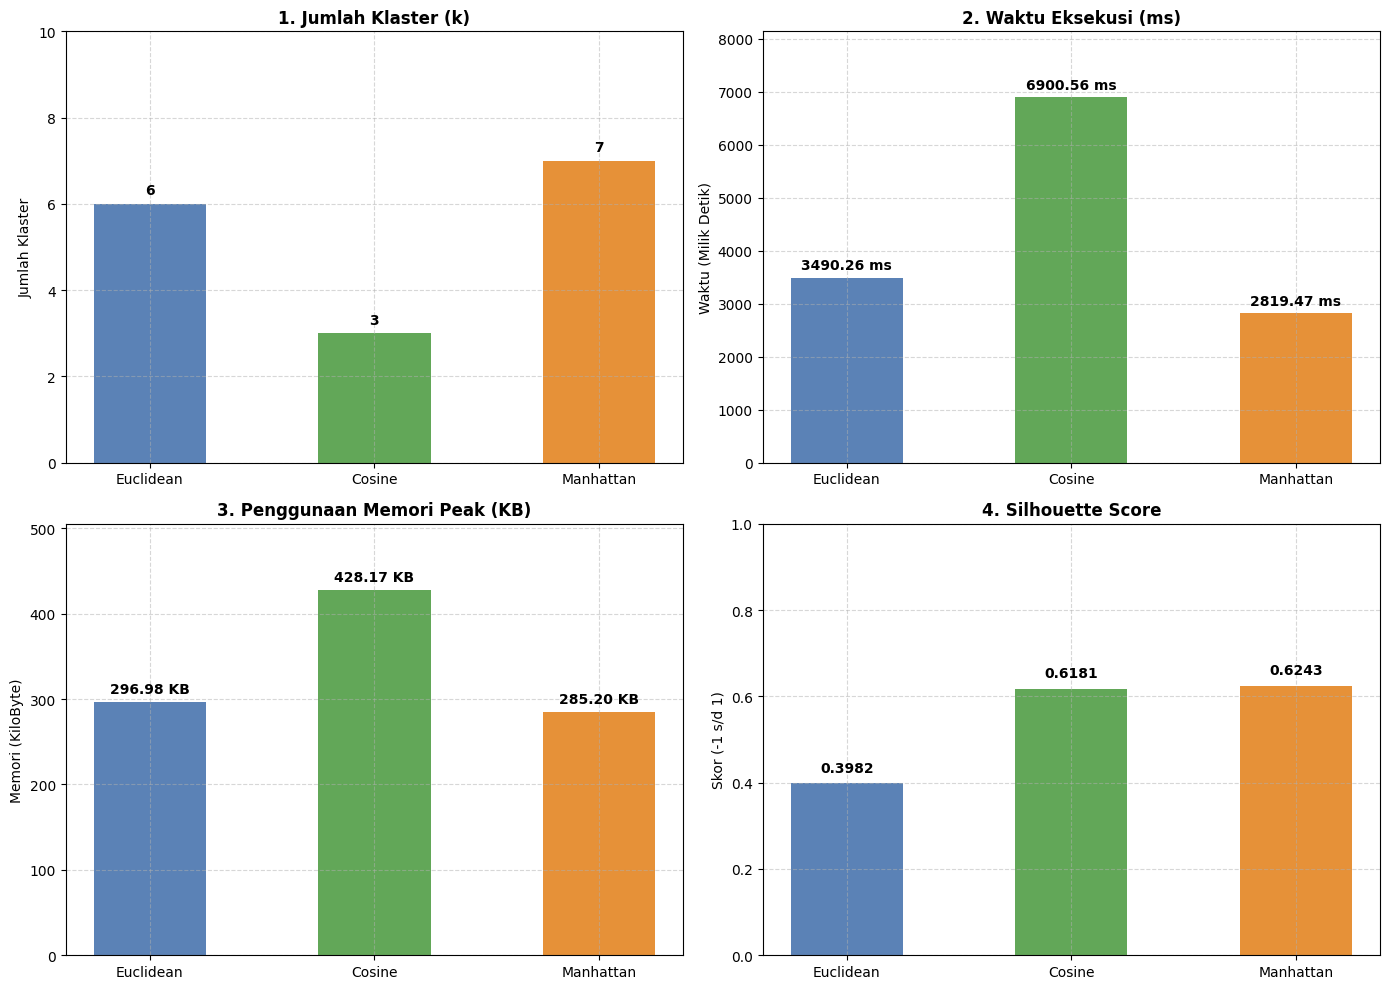

In [21]:
import matplotlib.pyplot as plt

# 1. Ekstraksi data secara dinamis dari DataFrame df_results
metrics = df_results["Metrik Jarak"].tolist()
clusters = df_results["Jumlah Klaster"].astype(int).tolist()
times = [float(x) for x in df_results["Waktu Eksekusi (ms)"]]
memories = [float(x) for x in df_results["Memori Peak (KB)"]]
silhouettes = [float(x) if str(x) != "N/A" else 0.0 for x in df_results["Silhouette Score"]]

# Skema Warna Batang (Euclidean=Biru, Cosine=Hijau, Manhattan=Oranye)
colors = ["#5b82b6", "#62a758", "#e69138"]

# 2. Membuat Plot Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Subplot 1: Jumlah Klaster ---
bars1 = axes[0, 0].bar(metrics, clusters, color=colors, width=0.5)
axes[0, 0].set_title("1. Jumlah Klaster (k)", fontweight="bold", fontsize=12)
axes[0, 0].set_ylabel("Jumlah Klaster", fontsize=10)
axes[0, 0].set_ylim(0, max(clusters) + 3)
axes[0, 0].grid(True, linestyle="--", alpha=0.5)
for bar in bars1:
    yval = bar.get_height()
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.15,
        f"{int(yval)}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Subplot 2: Waktu Eksekusi (ms) ---
bars2 = axes[0, 1].bar(metrics, times, color=colors, width=0.5)
axes[0, 1].set_title("2. Waktu Eksekusi (ms)", fontweight="bold", fontsize=12)
axes[0, 1].set_ylabel("Waktu (Milik Detik)", fontsize=10)
axes[0, 1].set_ylim(0, max(times) * 1.18)
axes[0, 1].grid(True, linestyle="--", alpha=0.5)
for bar in bars2:
    yval = bar.get_height()
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        yval + (max(times) * 0.015),
        f"{yval:.2f} ms",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Subplot 3: Penggunaan Memori Peak (KB) ---
bars3 = axes[1, 0].bar(metrics, memories, color=colors, width=0.5)
axes[1, 0].set_title("3. Penggunaan Memori Peak (KB)", fontweight="bold", fontsize=12)
axes[1, 0].set_ylabel("Memori (KiloByte)", fontsize=10)
axes[1, 0].set_ylim(0, max(memories) * 1.18)
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
for bar in bars3:
    yval = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        yval + (max(memories) * 0.015),
        f"{yval:.2f} KB",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Subplot 4: Silhouette Score ---
bars4 = axes[1, 1].bar(metrics, silhouettes, color=colors, width=0.5)
axes[1, 1].set_title("4. Silhouette Score", fontweight="bold", fontsize=12)
axes[1, 1].set_ylabel("Skor (-1 s/d 1)", fontsize=10)
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
for bar in bars4:
    yval = bar.get_height()
    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### **Analisis**

Berdasarkan hasil eksekusi eksperimen DBSCAN, Manhattan Distance terbukti sebagai metrik yang paling optimal. Metrik ini tidak hanya menghasilkan pembagian kluster paling tajam dengan Silhouette Score tertinggi sebesar 0,6243 untuk 7 kluster, tetapi juga mencatatkan efisiensi sumber daya terbaik melalui waktu eksekusi tercepat (2806,15 ms) dan konsumsi memori peak terendah (285,20 KB).

Di sisi lain, Cosine Distance mampu membentuk 3 kluster dengan Silhouette Score yang cukup baik (0,6181), namun membutuhkan beban komputasi paling tinggi dengan waktu eksekusi mencapai 6884,53 ms serta alokasi memori hingga 428,17 KB akibat kompleksitas perhitungan dot product dan norma vektor pada setiap pasangan data.

Sementara itu, Euclidean Distance mencatatkan performa pemisahan terendah dengan Silhouette Score sebesar 0,3982 untuk 6 kluster, yang menunjukkan bahwa perhitungan jarak lurus kurang efektif dalam memetakan kerapatan titik data pada konfigurasi nilai eps=0.35.